In [9]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.quick_calculate import FittingFunction
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [10]:
manual_db = pl.read_parquet(r".database\manual_detection_database.parquet")
auto_db = dp.combined_mask_no_merge.filter(pl.col("face") == "posx").collect()

manual_db

i,j,manual_detect_boulder_id,face
i32,i32,u32,str
7661,5626,7883757,"""posx"""
7661,5627,7883757,"""posx"""
7661,5628,7883757,"""posx"""
7661,5629,7883757,"""posx"""
7661,5630,7883757,"""posx"""
…,…,…,…
40,2454,10549449,"""posx"""
40,2455,10549449,"""posx"""
40,2456,10549449,"""posx"""


In [11]:
auto_db_agg = auto_db.group_by("row_id").agg(pl.len().alias("auto_boulder_size"))
manual_db_agg = manual_db.group_by("manual_detect_boulder_id").agg(pl.len().alias("manual_boulder_size"))

db_intersections = manual_db.join(
    auto_db,
    on=["i", "j"],
    how="inner",
).select("i", "j", "lod_level", "lod_code", "row_id", "manual_detect_boulder_id")

manual_db_agg

manual_detect_boulder_id,manual_boulder_size
u32,u32
10858411,20088
10549449,21584
1411612,58
559319,128
7324622,54999
…,…
13322687,42
7579290,72
2961614,87


In [12]:
db_intersections_agg = db_intersections.group_by("manual_detect_boulder_id", "row_id").agg(
    pl.len().alias("overlap"),
    pl.col("lod_level").first(),
    pl.col("lod_code").first()
)

db_jaccard = db_intersections_agg.join(
    auto_db_agg,
    on="row_id",
    how="left",
).join(
    manual_db_agg,
    on="manual_detect_boulder_id",
    how="left",
).with_columns(
    (
        pl.col("overlap") / (pl.col("auto_boulder_size") + pl.col("manual_boulder_size") - pl.col("overlap"))
    ).alias("Jaccard_index")
)

db_jaccard

manual_detect_boulder_id,row_id,overlap,lod_level,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index
u32,u32,u32,u8,str,u32,u32,f64
15932283,19601,2048,1,"""A""",2048,248654,0.008236
5505284,750999,209,4,"""ADAA""",209,17330,0.01206
5505284,751009,134,4,"""ADAA""",134,17330,0.007732
7193040,751238,12,4,"""ADAA""",843,18253,0.000629
5382605,762570,35,4,"""ADAB""",35,56462,0.00062
…,…,…,…,…,…,…,…
7872840,424322,47,3,"""ABD""",768,131095,0.000357
16005391,424419,456,3,"""ABD""",612,34462,0.013172
7872840,434511,23,4,"""ABDA""",622,131095,0.000175


In [13]:
db_jaccard_agg = (
    db_jaccard
    .group_by(["lod_level", "manual_detect_boulder_id"])
    .agg(
        pl.all().get(
            pl.col("Jaccard_index").arg_max()
        )
    )
).with_columns(
    (pl.col("manual_boulder_size") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size"),
    (pl.col("auto_boulder_size") / pl.col("manual_boulder_size")).alias("area_diff_factor")
)

db_jaccard_agg

lod_level,manual_detect_boulder_id,row_id,overlap,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index,viewport_size,area_diff_factor
u8,u32,u32,u32,str,u32,u32,f64,u32,f64
3,5535880,2381412,91,"""CBD""",124,120,0.594771,30,1.033333
3,1841114,1629686,128,"""BCD""",140,157,0.757396,39,0.89172
2,951257,1943273,609,"""CA""",640,749,0.780769,46,0.854473
1,12587705,19808,13821,"""A""",40000,14843,0.336917,231,2.694873
3,1817760,3193439,201,"""DBA""",228,304,0.607251,76,0.75
…,…,…,…,…,…,…,…,…,…
2,4087072,1432276,3664,"""BC""",3664,76253,0.048051,4765,0.048051
4,10732816,1834932,137,"""BDCB""",141,205,0.655502,205,0.687805
4,848155,859765,133,"""ADCA""",133,19927,0.006674,19927,0.006674


In [14]:
from sklearn.neighbors import KernelDensity

db_jaccard_agg_filter = db_jaccard_agg.filter(pl.col("viewport_size") > 0)
alphas = db_jaccard_agg_filter["viewport_size"].to_numpy()
j = db_jaccard_agg_filter["Jaccard_index"].to_numpy()

plotting_alphas = np.geomspace(1, 512**2, 500)
plotting_alphas_log = np.log(plotting_alphas)

def get_s_KDE(j_min, alpha_inputs : np.ndarray, bootstrap = False, bw_method=0.1):
    alphas_pass = alphas[j > j_min]

    log_alphas = np.log(alphas)
    log_alphas_pass = np.log(alphas_pass)

    if bootstrap:
        log_alphas = np.random.choice(log_alphas, size=len(log_alphas), replace=True)
        log_alphas_pass = np.random.choice(log_alphas_pass, size=len(log_alphas_pass), replace=True)

    # log_alphas_kde = lambda alpha : len(log_alphas) * gaussian_kde(log_alphas, bw_method=bw_method)(np.log(alpha)) / alpha
    # log_alphas_pass_kde = lambda alpha : len(log_alphas_pass) * gaussian_kde(log_alphas_pass, bw_method = bw_method)(np.log(alpha)) / alpha

    # Fit the KDEs
    kde_log_alphas = KernelDensity(
        kernel="epanechnikov",
        bandwidth="scott"
    ).fit(log_alphas[:, None])

    kde_log_alphas_pass = KernelDensity(
        kernel="epanechnikov",
        bandwidth="scott"
    ).fit(log_alphas_pass[:, None])

    # Equivalent functions
    log_alphas_kde = lambda alpha: (
        len(log_alphas)
        * np.exp(kde_log_alphas.score_samples(np.log(alpha).reshape(-1, 1)))
        / alpha
    )

    log_alphas_pass_kde = lambda alpha: (
        len(log_alphas_pass)
        * np.exp(kde_log_alphas_pass.score_samples(np.log(alpha).reshape(-1, 1)))
        / alpha
    )

    return np.divide(
        log_alphas_pass_kde(alpha_inputs),
        log_alphas_kde(alpha_inputs),
        out=np.zeros_like(alpha_inputs, dtype=float),
        where=log_alphas_kde(alpha_inputs) != 0
    )
    

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.0s finished


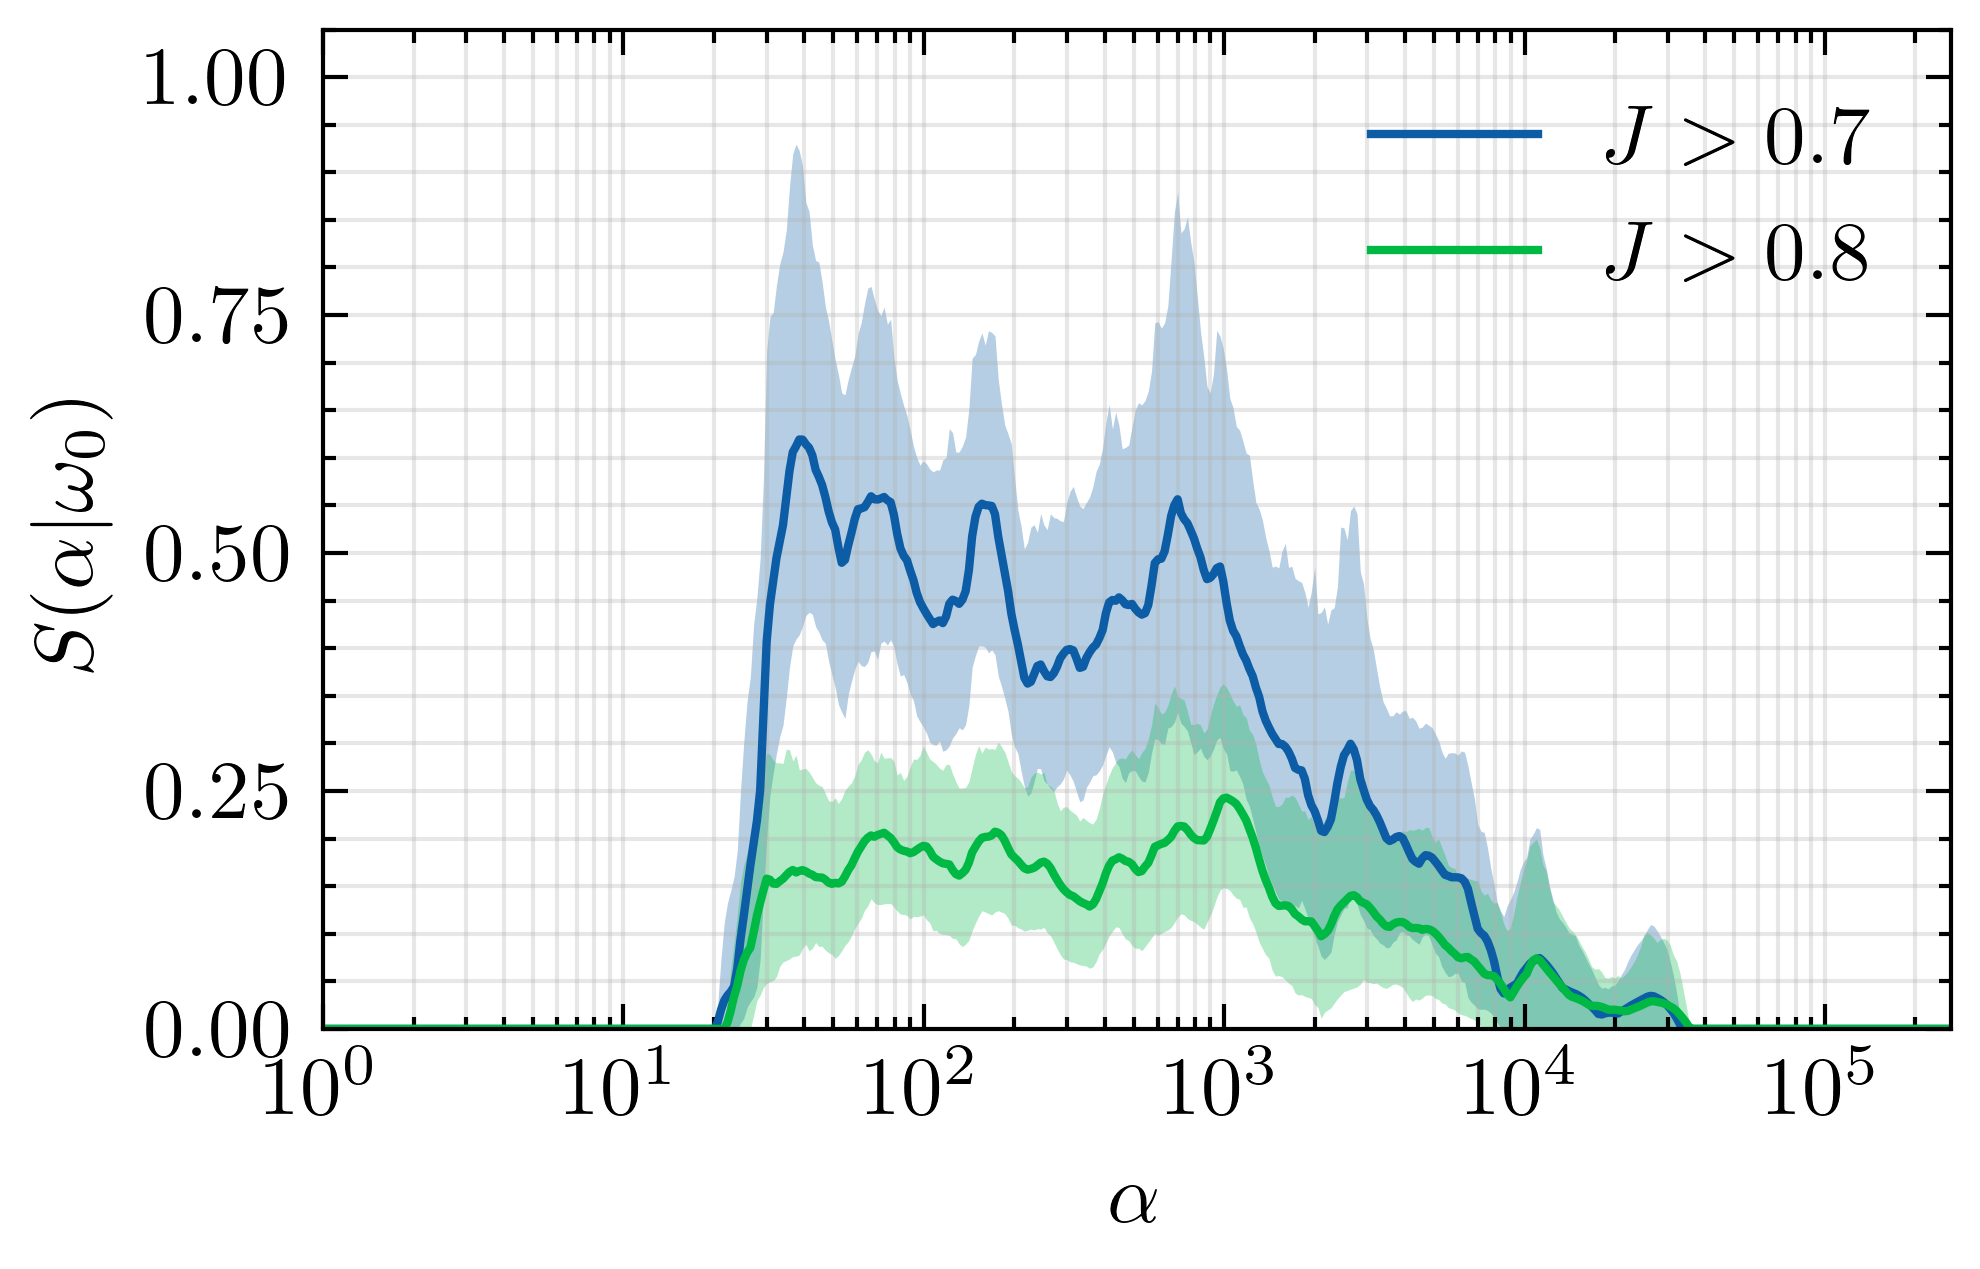

In [18]:
from joblib import Parallel, delayed

numb_bootstrap = 200
plotting_alphas = np.geomspace(1, 512**2, 500)

for c_code, j_min_plot in enumerate([0.7, 0.8]):
    
    bootstrap_kde_data = np.array(
        Parallel(n_jobs=-1, verbose = 1)(
            delayed(get_s_KDE)(
                j_min_plot,
                plotting_alphas,
                True,
                "scott"
            )
            for _ in range(numb_bootstrap)
        )
    ).T

    # Statistics
    mean_pdf = bootstrap_kde_data.mean(axis=1)
    lower = np.percentile(bootstrap_kde_data, 2.5, axis=1)
    upper = np.percentile(bootstrap_kde_data, 97.5, axis=1)

    # 95% confidence interval
    plt.fill_between(
        plotting_alphas, lower, upper,
        alpha=0.3,
        color= f"C{c_code}",
        linewidth = 0
    )

    # Mean bootstrap KsDE
    plt.plot(plotting_alphas, mean_pdf, label=rf"$J > {j_min_plot}$", c = f"C{c_code}")

plt.xscale("log")
# plt.yscale("log")
plt.ylim(0, 1.05)
plt.xlim(1, 512*512)
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$S(\alpha|\omega_0)$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.savefig("S_from_manual_detection.png")
plt.show()

In [16]:
# import numpy as np
# import matplotlib.pyplot as plt

# db_jaccard_agg_filter = db_jaccard_agg.filter(pl.col("viewport_size") > 0)
# alphas = db_jaccard_agg_filter["viewport_size"].to_numpy()
# j = db_jaccard_agg_filter["Jaccard_index"].to_numpy()

# auto_alphas = dp.boulder_agg_data.collect().with_columns(
#     (pl.col("alpha") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size")
# )["viewport_size"]

# plotting_alphas = np.geomspace(1, 512**2, 500)
# plotting_alphas_log = np.log(plotting_alphas)

# alphas_pass = alphas[j > 0.7]

# log_alphas = np.log(alphas)
# log_alphas_pass = np.log(alphas_pass)
# # log_auto_alphas = np.log(auto_alphas)

# log_alphas_kde = lambda alpha : len(log_alphas) * gaussian_kde(log_alphas)(np.log(alpha)) / alpha
# log_alphas_pass_kde = lambda alpha : len(log_alphas_pass) * gaussian_kde(log_alphas_pass)(np.log(alpha)) / alpha
# # log_auto_alphas_kde = lambda alpha : len(log_auto_alphas) * gaussian_kde(log_auto_alphas, bw_method = 0.01)(np.log(alpha)) / alpha

# plt.plot(plotting_alphas, log_alphas_kde(plotting_alphas), label="Total KDE")
# plt.plot(plotting_alphas, log_alphas_pass_kde(plotting_alphas), label="Success KDE")
# plt.xscale("log")
# plt.xlabel("Viewport size")
# plt.ylabel("Density")
# plt.legend()
# plt.show()